# Example 5: a neural ODE as a Model Exchange FMU

Examples 1-4 export a network that computes its output *directly* from its
inputs. This example is different: the network we train and export,
`f_theta(t, x)`, is only the **right-hand side of an ODE**,
`dx/dt = f_theta(t, x)`. ONNX2FMU wraps it as a **Model Exchange** FMU, and
it is the *FMI importer's own solver* (e.g. CVode) that integrates it at
simulation time -- ONNX2FMU never runs an internal solver over it.

The training target is a forced Van der Pol oscillator:

$$
\frac{\partial x_0}{\partial t} = x_1
$$

$$
\frac{\partial x_1}{\partial t} = (1 - x_0^2) \, x_1 - x_0 + A \, \sin(\omega t)
$$

which is why the exported network also takes the simulation time `t` as an
input, declared with `"time": true` in the model description -- the forcing
term makes the system non-autonomous. We train with
[torchdiffeq](https://github.com/rtqichen/torchdiffeq)'s `odeint`, which
integrates the candidate right-hand side during training and backpropagates
through the ODE solve -- the same "neural ODE" recipe from [Chen et al.
(2018)](https://arxiv.org/abs/1806.07366).

In [1]:
import copy
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
import onnx
import pandas as pd
import matplotlib.pyplot as plt
from torchdiffeq import odeint

torch.manual_seed(0)
np.random.seed(0)

## True dynamics and a reference integrator

Used both to generate training trajectories and, later, to check the compiled FMU.

In [2]:
A, OMEGA = 0.5, 1.0


def true_derivative(t: float, x: np.ndarray) -> np.ndarray:
    return np.array([
        x[1],
        (1.0 - x[0] ** 2) * x[1] - x[0] + A * np.sin(OMEGA * t),
    ])


def true_derivative_batch(t: float, X: np.ndarray) -> np.ndarray:
    """Same right-hand side, vectorised over a batch of states, shape (N, 2)."""
    return np.stack([
        X[:, 1],
        (1.0 - X[:, 0] ** 2) * X[:, 1] - X[:, 0] + A * np.sin(OMEGA * t),
    ], axis=1)


def rk4_trajectory(x0, t_eval, dt=1e-4):
    """Reference trajectory of the true dynamics, sampled at t_eval."""
    x = np.array(x0, dtype=float)
    t = 0.0
    out = [x.copy()]
    next_idx = 1
    n_steps = int(round(t_eval[-1] / dt))
    for _ in range(n_steps):
        k1 = true_derivative(t, x)
        k2 = true_derivative(t + dt / 2, x + dt / 2 * k1)
        k3 = true_derivative(t + dt / 2, x + dt / 2 * k2)
        k4 = true_derivative(t + dt, x + dt * k3)
        x = x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        t += dt
        if next_idx < len(t_eval) and abs(t - t_eval[next_idx]) < dt / 2:
            out.append(x.copy())
            next_idx += 1
    return np.array(out)


def rk4_batch(X0, t_eval, dt=1e-3):
    """Reference trajectories for many initial conditions at once.

    Same integrator as `rk4_trajectory`, stepping every initial condition
    together so that building a few hundred training trajectories costs a
    second rather than a minute. Returns shape (n_initial_conditions,
    len(t_eval), 2).
    """
    X = np.array(X0, dtype=float)
    t = 0.0
    out = [X.copy()]
    next_idx = 1
    n_steps = int(round(t_eval[-1] / dt))
    for _ in range(n_steps):
        k1 = true_derivative_batch(t, X)
        k2 = true_derivative_batch(t + dt / 2, X + dt / 2 * k1)
        k3 = true_derivative_batch(t + dt / 2, X + dt / 2 * k2)
        k4 = true_derivative_batch(t + dt, X + dt * k3)
        X = X + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        t += dt
        if next_idx < len(t_eval) and abs(t - t_eval[next_idx]) < dt / 2:
            out.append(X.copy())
            next_idx += 1
    return np.stack(out, axis=1)

An example trajectory of the Van der Pol oscillator with $A=0.5$ and $\omega=1.0$.

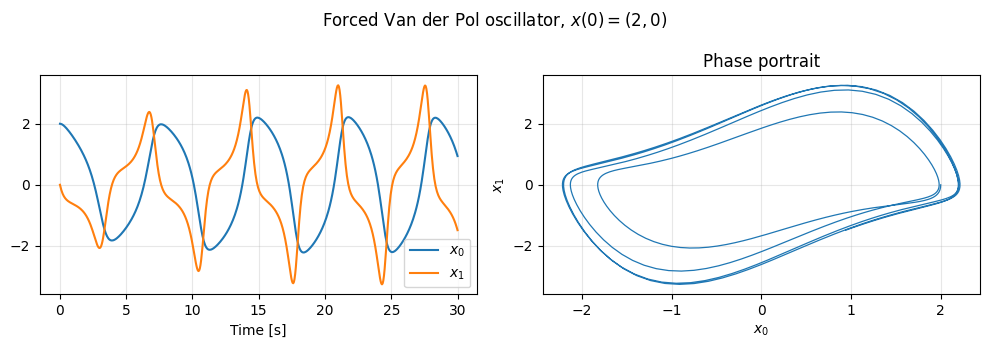

In [3]:
t_demo = np.linspace(0.0, 30.0, 601)
x_demo = rk4_batch([[2.0, 0.0]], t_demo)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t_demo, x_demo[:, 0], label="$x_0$")
axes[0].plot(t_demo, x_demo[:, 1], label="$x_1$")
axes[0].set_xlabel("Time [s]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(x_demo[:, 0], x_demo[:, 1], lw=0.9)
axes[1].set_xlabel("$x_0$")
axes[1].set_ylabel("$x_1$")
axes[1].set_title("Phase portrait")
axes[1].grid(True, alpha=0.3)
fig.suptitle("Forced Van der Pol oscillator, $x(0) = (2, 0)$")
plt.tight_layout()
plt.show()

## The network

`DerivativeNet` is the module we actually export to ONNX -- it takes the
state `x` and time `t` (ONNX2FMU's input order) and returns `dx/dt`.
`TorchdiffeqRHS` is a thin wrapper matching the `func(t, y)` signature
`torchdiffeq.odeint` expects.

Two details in `DerivativeNet` are worth more than any amount of extra
width, and both are generic rather than Van-der-Pol-specific:

- **Fourier time features.** Because the forcing makes the system
  non-autonomous, `t` is a genuine network input -- and a raw `t` sweeping
  0..30 s drives a `tanh` layer straight into saturation. Feeding
  `sin(w t)`, `cos(w t)` at a handful of fixed frequencies instead gives the
  network a bounded, periodic representation of time. This is a general fix
  for any FMU whose network sees simulation time directly.
- **A linear skip path.** The vector field is largely linear in those
  features, so a plain `nn.Linear` is wired in parallel with the `tanh`
  stack. The MLP then only has to represent the nonlinear remainder.

Both are ordinary ONNX ops (`Sin`, `Cos`, `Concat`, `Add`), so the exported
graph still loads in the ONNX Runtime that ONNX2FMU pins.

In [4]:
class DerivativeNet(nn.Module):
    """f_theta(x, t) -> dx/dt. This is the module exported to ONNX, with
    inputs in ONNX2FMU's order: state first, time second.

    Two choices here do most of the work for accuracy, and neither is
    specific to Van der Pol:

    * **Fourier time features.** The forcing makes the system
      non-autonomous, so `t` is a real input -- but a raw `t` sweeping
      0..30 s saturates a `tanh` layer almost immediately. Encoding it as
      `sin`/`cos` at a few fixed frequencies gives the network a bounded,
      periodic picture of time instead. `Sin`, `Cos` and `Concat` all
      export to ONNX and run in ONNX Runtime, so the FMU is unaffected.
    * **A linear skip path.** Most of `dx/dt` is linear in those features.
      Letting a plain `nn.Linear` carry that part directly leaves the
      `tanh` stack to model only the nonlinear remainder.
    """

    def __init__(self, hidden: int = 128, freqs=(0.25, 0.5, 1.0, 2.0),
                 depth: int = 2):
        super().__init__()
        self.register_buffer("freqs", torch.tensor(freqs, dtype=torch.float32))
        n_in = 2 + 2 * len(freqs)
        layers = [nn.Linear(n_in, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 2)]
        self.net = nn.Sequential(*layers)
        self.skip = nn.Linear(n_in, 2)

    def features(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """[x, sin(w*t), cos(w*t)], with t broadcast over x's batch shape."""
        if x.dim() > 1:
            t_col = t.reshape(-1, 1).expand(x.shape[0], 1)
        else:
            t_col = t.reshape(1, 1)
        angles = t_col * self.freqs
        feats = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        if x.dim() == 1:
            feats = feats.reshape(-1)
        return torch.cat([x, feats], dim=-1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        z = self.features(x, t)
        return self.net(z) + self.skip(z)


class TorchdiffeqRHS(nn.Module):
    """torchdiffeq.odeint calls func(t, y); wrap DerivativeNet to match.

    `t_offset` shifts the solver's time. Training below integrates short
    segments cut from different points of the 30 s horizon, all sharing one
    relative time grid; the offset is what lets each segment in the batch
    see its own absolute time, which the forcing term needs.
    """

    def __init__(self, net: DerivativeNet, t_offset=0.0):
        super().__init__()
        self.net = net
        self.t_offset = t_offset

    def forward(self, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.net(y, t + self.t_offset)

## Training data

256 trajectories from random initial conditions, integrated with the true
dynamics over the same 30 s horizon we'll later simulate the FMU over, and
sampled every 0.05 s. The batched integrator from above makes this cost about
a second.

In [5]:
def make_training_set(n_trajectories=256, t_span=30.0, dt=0.05, seed=0):
    """Reference trajectories from random initial conditions.

    The grid is sampled every 0.05 s, far more densely than the 0.15 s the
    FMU is reported at later on. That resolution is what lets the
    short-window term of the loss below see the vector field on the scale it
    actually varies.

    Returns the time grid and a (n_trajectories, n_points, 2) tensor.
    """
    rng = np.random.RandomState(seed)
    t_grid = np.arange(0.0, t_span + dt / 2, dt)
    x0s = rng.uniform(low=[-2.5, -2.5], high=[2.5, 2.5],
                      size=(n_trajectories, 2))
    trajectories = rk4_batch(x0s, t_grid)
    return (
        torch.tensor(t_grid, dtype=torch.float32),
        torch.tensor(trajectories, dtype=torch.float32),
    )

## Training loop

Every iteration integrates the *candidate* right-hand side with `odeint` and
backpropagates the trajectory error -- this is what makes it a neural ODE
rather than a plain regression on the vector field. Two things differ from
the textbook version, and together they are what brings the error down:

- **Random short segments instead of one long rollout.** Rather than
  re-integrating the full 30 s horizon from a fixed set of initial
  conditions on every iteration, each step samples a fresh batch of windows
  cut from random points of random trajectories. Every iteration therefore
  sees new data and costs a fraction as much, and the gradient does not have
  to travel through 600 solver steps to reach the parameters.
- **Two window lengths at once.** A batch of very short windows (3 samples,
  0.1 s) pins down the vector field locally, which is what long-horizon
  accuracy ultimately rests on; a batch of longer windows -- grown from 1 s
  to 5 s over the first half of training -- keeps the *integrated* solution
  honest. Optimising only the long rollout leaves the field itself
  surprisingly inaccurate; optimising only short windows drifts.

Because rollout error over five oscillation periods is not a monotone
function of the training loss, the loop tracks the weights that roll out best
on eight held-out trajectories and returns those.

In [6]:
def segment_loss(rhs, t_grid, trajectories, rng, window, batch, step=0.05):
    """Integrate `batch` random segments of `window` samples and score them.

    Each segment starts at a different sample of a different trajectory, so
    they share only a *relative* time grid; `rhs.t_offset` carries each one's
    absolute start time into the forcing term.
    """
    n_trajectories, n_points, _ = trajectories.shape
    starts = rng.randint(0, n_points - window, size=batch)
    idx = starts[:, None] + np.arange(window)[None, :]
    target = trajectories[rng.randint(0, n_trajectories, size=batch)[:, None], idx]
    rhs.t_offset = t_grid[starts].reshape(-1, 1)
    t_rel = t_grid[:window] - t_grid[0]
    pred = odeint(rhs, target[:, 0], t_rel, method="rk4",
                  options={"step_size": step})
    return torch.mean((pred - target.transpose(0, 1)) ** 2)


def rollout_error(net, t_grid, trajectories):
    """Full-horizon rollouts from held-out initial states, scored two ways.

    Returns (rms, worst). Selection below uses the RMS: a couple of initial
    conditions sit near the unstable fixed point, where the trajectory spends
    a long time spiralling out and its *phase* is badly conditioned, so their
    error saturates at roughly the oscillation amplitude however good the
    model is. Picking checkpoints on the worst case just tracks those two and
    ignores everything else.
    """
    with torch.no_grad():
        pred = odeint(TorchdiffeqRHS(net), trajectories[:, 0], t_grid,
                      method="rk4", options={"step_size": 0.02})
    err = (pred - trajectories.transpose(0, 1)).abs()
    return err.pow(2).mean().sqrt().item(), err.max().item()


def train(n_iters=10000, lr=3e-3, short_window=3, short_batch=512,
          long_window=(20, 100), long_batch=32, w_short=400.0, w_long=0.3,
          seed=0):
    torch.manual_seed(seed)
    t_grid, trajectories = make_training_set(seed=seed)
    _, val_trajectories = make_training_set(n_trajectories=8, seed=seed + 99)

    net = DerivativeNet()
    rhs = TorchdiffeqRHS(net)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_iters, eta_min=lr * 3e-3)
    rng = np.random.RandomState(seed + 1)
    best_err, best_state = float("inf"), copy.deepcopy(net.state_dict())

    for it in range(n_iters):
        # The long window grows over the first half of training: a network
        # that cannot yet integrate 1 s correctly learns nothing useful from
        # a 5 s rollout.
        grown = min(1.0, 2.0 * it / max(n_iters - 1, 1))
        window = int(round(long_window[0]
                           + (long_window[1] - long_window[0]) * grown))

        optimizer.zero_grad()
        short_loss = segment_loss(rhs, t_grid, trajectories, rng,
                                  short_window, short_batch)
        long_loss = segment_loss(rhs, t_grid, trajectories, rng,
                                 window, long_batch)
        (w_short * short_loss + w_long * long_loss).backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if it % 250 == 0 or it == n_iters - 1:
            err, worst = rollout_error(net, t_grid, val_trajectories)
            if err < best_err:
                best_err, best_state = err, copy.deepcopy(net.state_dict())
            print(f"iter {it:5d}  short {short_loss.item():.2e}  "
                  f"long {long_loss.item():.2e}  window {window:3d}  "
                  f"lr {scheduler.get_last_lr()[0]:.2e}  "
                  f"held-out rms {err:.4f}  worst {worst:.4f}")

    # Long-horizon rollout error is not monotone in the training loss, so keep
    # the weights that actually rolled out best on the held-out trajectories.
    net.load_state_dict(best_state)
    print(f"\nbest held-out rollout RMS: {best_err:.4f}")
    return net

## Train, or load cached weights

Training takes a few minutes. Once it has run once, `train()`'s weights are
cached to `example5_weights.pt` next to the notebook, so re-running top to
bottom afterwards just loads them instead of retraining. Delete that file,
or set `FORCE_RETRAIN = True`, to train again.

In [7]:
WEIGHTS_PATH = Path("example5_weights.pt")
FORCE_RETRAIN = False

if WEIGHTS_PATH.exists() and not FORCE_RETRAIN:
    net = DerivativeNet()
    net.load_state_dict(torch.load(WEIGHTS_PATH, map_location="cpu"))
    net.eval()
    print(f"loaded cached weights from {WEIGHTS_PATH}")
else:
    net = train()
    torch.save(net.state_dict(), WEIGHTS_PATH)
    print(f"trained and saved weights to {WEIGHTS_PATH}")

loaded cached weights from example5_weights.pt


## Export to ONNX

Only `DerivativeNet` -- the vector field -- is exported. The FMU does **not**
embed a solver; the FMI importer supplies its own when it drives the FMU in
Model Exchange mode.

In [8]:
net.eval()
x_example = torch.tensor([2.0, 0.0])
# ONNX2FMU requires every declared node to have rank >= 1 (a 0-d scalar
# shape is rejected), so "t" must be exported with shape (1,), not as a
# bare scalar tensor.
t_example = torch.tensor([0.0])
torch.onnx.export(
    net, (x_example, t_example), "example5.onnx",
    input_names=["x", "t"],
    output_names=["dx"],
)

onnx_model = onnx.load("example5.onnx")
onnx.checker.check_model(onnx_model)
# Pin the IR version to what the pinned ONNX Runtime release in
# onnx2fmu/CMakeLists.txt actually supports (avoids a load failure if the
# local `onnx` package is newer than the pinned ORT release).
onnx_model.ir_version = 10
onnx_model.graph.doc_string = (
    "Right-hand side of a forced Van der Pol neural ODE, "
    "trained with torchdiffeq."
)
onnx.save(onnx_model, "example5.onnx")
# The exporter may spill the weights into a sidecar `example5.onnx.data`;
# re-saving above inlines them again. ONNX2FMU copies only the `.onnx` into
# the FMU's resources, so drop the sidecar rather than leave a stale one
# next to a self-contained model.
Path("example5.onnx.data").unlink(missing_ok=True)
print(f"exported {Path('example5.onnx').stat().st_size / 1024:.0f} kB, ops: "
      f"{sorted({n.op_type for n in onnx_model.graph.node})}")

W0828 17:27:29.187000 3898167 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `DerivativeNet([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `DerivativeNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
exported 88 kB, ops: ['Add', 'Concat', 'Cos', 'MatMul', 'Mul', 'Reshape', 'Sin', 'Tanh']


## Model description

- `"FMUType": ["ModelExchange", "CoSimulation"]` builds both interfaces.
- The state `"x"` is reclassified by ONNX2FMU as an `output`-causality,
`initial="exact"` variable and **must** declare `"start"` (its initial
condition).
- `"t"` is flagged `"time": true`: ONNX2FMU feeds it the FMI independent
variable on every evaluation instead of generating an FMI variable for it.
- `"dx"` declares `"derivativeOf": "x"`, so ONNX2FMU emits it as a
`local`-causality, `initial="calculated"` variable carrying the FMI
`derivative` attribute.

In [9]:
model_description = {
    "name": "example5",
    "description": (
        "Neural ODE (trained with torchdiffeq) approximating a forced "
        "Van der Pol oscillator. dx/dt = f_theta(t, x); the FMU's own "
        "Model Exchange solver integrates it."
    ),
    "FMIVersion": "3.0",
    "FMUType": ["ModelExchange", "CoSimulation"],
    "inputs": [
        {
            "name": "x",
            "description": "State vector [x0, x1].",
            "labels": ["x0", "x1"],
            "start": [2.0, 0.0],
        },
        {
            "name": "t",
            "description": "Simulation time, fed to the forcing term.",
            "time": True,
        },
    ],
    "outputs": [
        {
            "name": "dx",
            "description": "dx/dt, the learned state derivative.",
            "labels": ["der_x0", "der_x1"],
            "derivativeOf": "x",
        },
    ],
}

with open("example5Description.json", "w", encoding="utf-8") as f:
    json.dump(model_description, f, indent=4)

## Reference trajectory

The *true* dynamics, sampled the same way `fmpy` will sample the compiled FMU -- used to sanity-check the trained network end-to-end (see the project README's Model Exchange section for how to build and simulate the FMU with `onnx2fmu`/`fmpy`).

In [10]:
x0, t_span, n_points = (2.0, 0.0), 30, 200
t_eval = np.linspace(0.0, t_span, n_points)
trajectory = rk4_trajectory(list(x0), t_eval)

df = pd.DataFrame(trajectory, columns=["x_0", "x_1"])
df["time"] = t_eval
df.set_index("time", inplace=True)
df.to_csv("Example5_ref.csv")
df

,x_0,x_1
time,,
0.000000,2.000000,0.000000
0.150754,1.980603,-0.237470
0.301508,1.933090,-0.381324
0.452261,1.868316,-0.471139
0.603015,1.792534,-0.531035
...,...,...
29.396985,1.623631,-0.867577
29.547739,1.484997,-0.975612
29.698492,1.328268,-1.107764


## Build and simulate the FMU

Build the Model Exchange/Co-Simulation FMU from the exported ONNX model and
run it through `fmpy`. Passing `fmi_type="ModelExchange"` makes `fmpy` drive
the FMU with its own solver (`CVode` by default) via
`getContinuousStates`/`setContinuousStates`/`getDerivatives` -- exactly the
mechanism described in the README's Model Exchange section -- rather than
stepping the network internally as ONNX2FMU's Co-Simulation interface would.
The state `x` is exposed as `x_0`/`x_1` and integrated by the solver; no
input needs to be supplied since the FMU already declares `x`'s initial
condition and the time input via `start`/`time: true`.

**`output_interval` is a sampling grid, not a step size.** CVode is an
adaptive integrator and chooses its own internal steps; `output_interval`
only says how densely to *report* the resulting trajectory. So this call is
already a variable-step simulation -- the step sizes are simply not visible
from here. The next section drives the same FMU with an explicit adaptive
stepper so they can be inspected.

In [11]:
from onnx2fmu.app import build

build(
    model_path="example5.onnx",
    model_description_path="example5Description.json",
    target_folder="temp",
    destination="example5.fmu",
)

2026-08-28 17:27:34.164 | INFO     | onnx2fmu.app:compile:296 - Call cmake -S temp -B temp/build -D MODEL_NAME=example5 -D FMI_VERSION=3


2026-08-28 17:27:34.606 | INFO     | onnx2fmu.app:compile:298 - CMake build cmake --build temp/build --config Release


In [12]:
from fmpy import simulate_fmu

results = simulate_fmu(
    "example5.fmu",
    fmi_type="ModelExchange",
    solver="CVode",
    start_time=t_eval[0],
    stop_time=t_eval[-1],
    output_interval=t_eval[1] - t_eval[0],
    output=["x_0", "x_1"],
    validate=True,
)

fmu_df = pd.DataFrame(results).set_index("time")
fmu_df

,x_0,x_1
time,,
0.000000,2.000000,0.000000
0.150754,1.982601,-0.236928
0.301508,1.936997,-0.374285
0.452261,1.875266,-0.461488
0.603015,1.803152,-0.522980
...,...,...
29.396985,1.628600,-0.866723
29.547739,1.490356,-0.973968
29.698492,1.334013,-1.103640


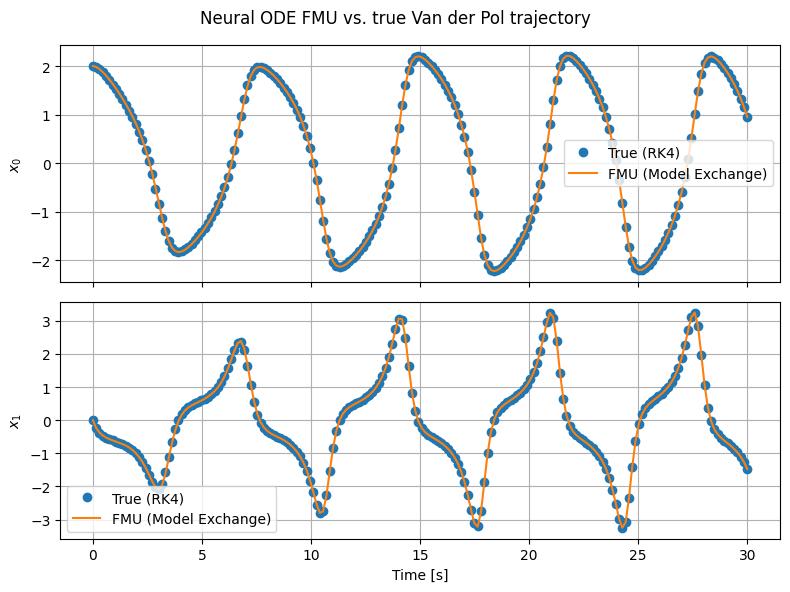

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for ax, col, label in zip(axes, ["x_0", "x_1"], ["$x_0$", "$x_1$"]):
    ax.plot(df.index, df[col], "o", label="True (RK4)")
    ax.plot(fmu_df.index, fmu_df[col], "-", label="FMU (Model Exchange)")
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Neural ODE FMU vs. true Van der Pol trajectory")
plt.tight_layout()
plt.show()

## Driving the FMU with your own adaptive stepper

Because the exported network is *only* the vector field `f_theta(x, t)`, the
Model Exchange FMU is a pure, stateless, re-entrant function: it answers
`dx/dt` for whatever `(t, x)` it is handed, and holds no notion of a step
size anywhere. That is what makes it usable by any adaptive solver, not just
`fmpy`'s built-in CVode.

Here we bypass `simulate_fmu` and call the FMI 3.0 interface directly, letting
`scipy.integrate.solve_ivp` own step-size control. The loop is just
`setTime` -> `setContinuousStates` -> `getContinuousStateDerivatives`.

Two API details worth noting:

- After `exitInitializationMode()` a Model Exchange FMU is *already* in Event
  Mode, so calling `enterEventMode()` here is an illegal call sequence.
- `fmpy`'s FMI 3.0 state accessors need caller-allocated `ctypes` buffers
  rather than plain Python lists.

`rtol=1e-6` is deliberate rather than conservative: the generated `model.c`
downcasts states to `float32` for ONNX Runtime inference, so derivatives carry
only ~1e-7 relative accuracy. Asking for a tighter tolerance makes the error
estimator chase quantization noise and the solver shrinks its step without
ever passing its tolerance test. See issue #51.

In [14]:
from ctypes import c_double

from fmpy import extract, read_model_description
from fmpy.fmi3 import FMU3Model
from scipy.integrate import solve_ivp

NX = 2


def open_me_instance(fmu_path="example5.fmu", start_time=0.0):
    """Instantiate the FMU in Model Exchange mode, ready for Continuous Time."""
    md = read_model_description(fmu_path)
    fmu = FMU3Model(
        guid=md.guid,
        modelIdentifier=md.modelExchange.modelIdentifier,
        unzipDirectory=extract(fmu_path),
        instanceName="me",
    )
    fmu.instantiate()
    fmu.enterInitializationMode(startTime=start_time)
    fmu.exitInitializationMode()
    # Already in Event Mode here -- do NOT call enterEventMode().
    fmu.updateDiscreteStates()
    fmu.enterContinuousTimeMode()
    return fmu


def make_fmu_rhs(fmu):
    """Wrap the FMU's vector field as a solve_ivp-compatible f(t, x)."""
    def rhs(t, x):
        fmu.setTime(t)
        fmu.setContinuousStates((c_double * NX)(*x), NX)
        dx = (c_double * NX)()
        fmu.getContinuousStateDerivatives(dx, NX)
        return np.array(dx[:])
    return rhs


fmu = open_me_instance()
try:
    x_init = (c_double * NX)()
    fmu.getContinuousStates(x_init, NX)
    x_init = np.array(x_init[:])
    print("initial state read from the FMU:", x_init)

    adaptive = solve_ivp(
        make_fmu_rhs(fmu), (t_eval[0], t_eval[-1]), x_init,
        method="LSODA", rtol=1e-6, atol=1e-8,
        t_eval=t_eval, dense_output=True,
    )
finally:
    fmu.terminate()
    fmu.freeInstance()

steps = np.diff(adaptive.sol.ts)
print(f"status {adaptive.status}  |  rhs evaluations {adaptive.nfev}")
print(f"accepted internal steps {len(adaptive.sol.ts)}")
print(f"internal step size  min {steps.min():.4g}  max {steps.max():.4g}  "
      f"ratio {steps.max() / steps.min():.0f}x")

adaptive_df = pd.DataFrame(adaptive.y.T, columns=["x_0", "x_1"], index=adaptive.t)
adaptive_df.index.name = "time"
adaptive_df.tail()

initial state read from the FMU: [2. 0.]
status 0  |  rhs evaluations 1913
accepted internal steps 876
internal step size  min 4.816e-06  max 0.09653  ratio 20044x


,x_0,x_1
time,,
29.396985,1.628822,-0.866603
29.547739,1.490607,-0.973655
29.698492,1.334325,-1.103317
29.849246,1.156115,-1.266178
30.000000,0.950454,-1.474925


### The same network, integrated adaptively in PyTorch

`net` accepts arbitrary `t` too, so we can integrate the *same* weights with
`torchdiffeq`'s adaptive `dopri5` -- dropping the fixed `method="rk4"` /
`step_size=0.05` options used during training. This gives a three-way check:
PyTorch adaptive vs. FMU adaptive vs. the true dynamics.

Agreement between the first two isolates the export-and-compile path: any
disagreement is ONNX conversion or the float32 boundary in the generated C,
*not* model quality, since the weights are identical.

In [15]:
with torch.no_grad():
    torch_adaptive = odeint(
        TorchdiffeqRHS(net),
        torch.tensor(x_init, dtype=torch.float32),
        torch.tensor(t_eval, dtype=torch.float32),
        method="dopri5", rtol=1e-6, atol=1e-8,
    ).numpy()

torch_df = pd.DataFrame(torch_adaptive, columns=["x_0", "x_1"], index=t_eval)
torch_df.index.name = "time"

export_gap = np.abs(torch_df.values - adaptive_df.values).max()
print(f"max |PyTorch adaptive - FMU adaptive| = {export_gap:.3e}")
print("(this measures the ONNX export + float32 C boundary, not model quality)")

max |PyTorch adaptive - FMU adaptive| = 6.667e-05
(this measures the ONNX export + float32 C boundary, not model quality)


## Separating model error from solver error

The plot above compares the FMU against the true RK4 reference, which mixes
two unrelated error sources:

1. **Model error** -- `f_theta` is only an approximation of the true Van der
   Pol vector field, limited by how far training converged.
2. **Solver error** -- the integrator's own truncation error.

Mixing them invites the reader to see the visible gap as an integration
artifact, which it is not. To separate them, integrate the *true* dynamics and
the *FMU* with byte-for-byte identical solver settings: whatever remains is
attributable to the network alone.

In [16]:
SOLVER_KW = dict(method="LSODA", rtol=1e-6, atol=1e-8, t_eval=t_eval)

# Same solver, same tolerances, same output grid -- only the vector field differs.
true_adaptive = solve_ivp(
    true_derivative, (t_eval[0], t_eval[-1]), x_init, **SOLVER_KW)
true_adaptive_df = pd.DataFrame(
    true_adaptive.y.T, columns=["x_0", "x_1"], index=true_adaptive.t)

model_error = np.abs(adaptive_df.values - true_adaptive_df.values).max()
solver_error = np.abs(true_adaptive_df.values - df.values).max()
total_error = np.abs(adaptive_df.values - df.values).max()

print(f"model error   (FMU  vs true, same solver)  : {model_error:.4f}")
print(f"solver error  (true vs committed RK4 ref)  : {solver_error:.2e}")
print(f"total         (FMU  vs committed RK4 ref)  : {total_error:.4f}")
print()
print(f"the network accounts for {model_error / solver_error:.0f}x more error "
      f"than the integrator")
print(f"rhs evaluations: FMU {adaptive.nfev}, true dynamics {true_adaptive.nfev}")

model error   (FMU  vs true, same solver)  : 0.0669
solver error  (true vs committed RK4 ref)  : 3.02e-04
total         (FMU  vs committed RK4 ref)  : 0.0668

the network accounts for 222x more error than the integrator
rhs evaluations: FMU 1913, true dynamics 1464


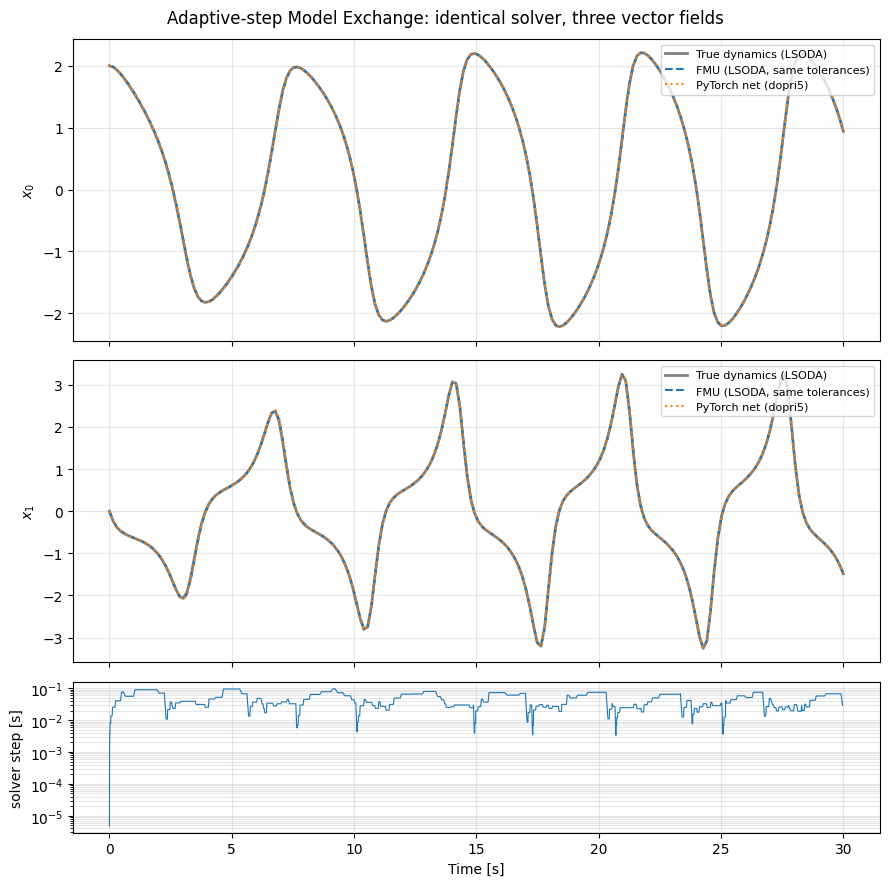

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

for ax, col, label in zip(axes[:2], ["x_0", "x_1"], ["$x_0$", "$x_1$"]):
    ax.plot(true_adaptive_df.index, true_adaptive_df[col], "k-",
            lw=2, alpha=0.5, label="True dynamics (LSODA)")
    ax.plot(adaptive_df.index, adaptive_df[col], "C0--",
            label="FMU (LSODA, same tolerances)")
    ax.plot(torch_df.index, torch_df[col], "C1:",
            label="PyTorch net (dopri5)")
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

# Step sizes the solver actually chose while driving the FMU.
axes[2].semilogy(adaptive.sol.ts[:-1], steps, "C0-", lw=0.8)
axes[2].set_ylabel("solver step [s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True, alpha=0.3, which="both")

fig.suptitle("Adaptive-step Model Exchange: identical solver, three vector fields")
plt.tight_layout()
plt.show()